# Two-GPU `mesh_halo` simulation

{bdg-danger}`2 CUDA GPUs required` {bdg-secondary}`256^3 particles` {bdg-success}`pre-executed production run`

This is the recommended PM++ execution path.  The published outputs were generated on
two GPUs and are rendered from the notebook file; Read the Docs never executes this run.
Each device owns an authoritative x slab.  Particles migrate when they cross a slab
boundary, while short mesh halos carry the CIC stencil across that boundary.

```{admonition} Committed execution record
:class: note
All outputs and plots on this page are committed in the notebook; hosted documentation
does not execute them.  The first executed output is the environment and configuration
record for the published run.
```


In [1]:
%matplotlib inline
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from pmpp.boltzmann import boltzmann
from pmpp.configuration import Configuration
from pmpp.cosmo import SimpleLCDM
from pmpp.lpt import lpt
from pmpp.modes import linear_modes, white_noise
from pmpp.multigpu_configuration import MultiGPUConfiguration
from pmpp.nbody import nbody
from pmpp.scatter import scatter
from pmpp.utils import create_compute_mesh

gpu_devices = [device for device in jax.devices() if device.platform == "gpu"][:2]
if len(gpu_devices) != 2:
    raise RuntimeError("This precomputed notebook requires exactly two visible CUDA devices.")

SEED = 11
RESOLUTION = 256
BOX_SIZE = 200.0
execution_record = {
    "jax_version": jax.__version__,
    "backend": jax.default_backend(),
    "selected_device_count": len(gpu_devices),
    "visible_device_count": len(jax.devices()),
    "selected_device_models": [device.device_kind for device in gpu_devices],
    "seed": SEED,
    "configuration": {
        "box_size_mpc_h": BOX_SIZE,
        "particle_grid": (RESOLUTION,) * 3,
        "mesh_ratio": 1,
        "lpt_order": 2,
        "a_start": 1 / 64,
        "a_stop": 1.0,
        "a_nbody_maxstep": 1 / 64,
        "mode": "mesh_halo",
    },
    "capacities": {
        "max_ptcl_per_slice": 10_066_329,
        "max_share_ptcl": 1_600_000,
        "max_halo_share_ptcl": 800_000,
        "max_share_gather_ptcl": 1_800_000,
    },
}
print("PM++ DOCUMENTATION EXECUTION RECORD")
for key, value in execution_record.items():
    print(f"{key}: {value}")
compute_mesh = create_compute_mesh(gpu_devices)
conf = Configuration(
    ptcl_spacing=BOX_SIZE / RESOLUTION,
    ptcl_grid_shape=(RESOLUTION,) * 3,
    mesh_shape=1,
    multigpu=MultiGPUConfiguration(compute_mesh=compute_mesh, mode="mesh_halo"),
    max_ptcl_per_slice=10_066_329,
    max_share_ptcl=1_600_000,
    max_halo_share_ptcl=800_000,
    max_share_gather_ptcl=1_800_000,
    lpt_order=2,
    a_start=1 / 64,
    a_stop=1.0,
    a_nbody_maxstep=1 / 64,
    float_dtype=jnp.float32,
)

print("devices:", [device.device_kind for device in gpu_devices])
print("logical mesh:", compute_mesh)
print(f"schedule: a={conf.a_start:.6f} to {conf.a_stop:.1f} in {conf.a_nbody_num} intervals")


PM++ DOCUMENTATION EXECUTION RECORD
jax_version: 0.6.2
backend: gpu
selected_device_count: 2
visible_device_count: 2
selected_device_models: ['NVIDIA GeForce RTX 3090', 'NVIDIA GeForce RTX 3090']
seed: 11
configuration: {'box_size_mpc_h': 200.0, 'particle_grid': (256, 256, 256), 'mesh_ratio': 1, 'lpt_order': 2, 'a_start': 0.015625, 'a_stop': 1.0, 'a_nbody_maxstep': 0.015625, 'mode': 'mesh_halo'}
capacities: {'max_ptcl_per_slice': 10066329, 'max_share_ptcl': 1600000, 'max_halo_share_ptcl': 800000, 'max_share_gather_ptcl': 1800000}


devices: ['NVIDIA GeForce RTX 3090', 'NVIDIA GeForce RTX 3090']
logical mesh: Mesh('gpus': 2, axis_types=(Auto,))
schedule: a=0.015625 to 1.0 in 63 intervals


## Slab geometry and static capacities

For a 256-cell x axis, device 0 owns `[0, 128)` and device 1 owns `[128, 256)`.
`owned_slice_end` is periodic, so the second endpoint is stored as zero.  The capacities
below are hard limits, not tuning hints: any overflow diagnostic invalidates a run.


In [2]:
starts = np.asarray(conf.owned_slice_start)
slab_width = RESOLUTION // len(gpu_devices)
slab_rows = [
    {
        "logical_device": logical_device,
        "physical_device_id": gpu_devices[logical_device].id,
        "owned_x_cells": f"[{logical_device * slab_width}, {(logical_device + 1) * slab_width})",
        "stored_periodic_start": int(starts[logical_device]),
    }
    for logical_device in range(2)
]

capacity_summary = {
    "max_ptcl_per_slice": conf.max_ptcl_per_slice,
    "max_share_ptcl": conf.max_share_ptcl,
    "max_halo_share_ptcl": conf.max_halo_share_ptcl,
    "max_share_gather_ptcl": conf.max_share_gather_ptcl,
    "mesh_halo_width": conf.mesh_halo_width,
    "local_mesh_shape": conf.local_mesh_shape,
}
print("slabs:", slab_rows)
print("capacities:", capacity_summary)


slabs: [{'logical_device': 0, 'physical_device_id': 0, 'owned_x_cells': '[0, 128)', 'stored_periodic_start': 0}, {'logical_device': 1, 'physical_device_id': 1, 'owned_x_cells': '[128, 256)', 'stored_periodic_start': 128}]
capacities: {'max_ptcl_per_slice': 10066329, 'max_share_ptcl': 1600000, 'max_halo_share_ptcl': 800000, 'max_share_gather_ptcl': 1800000, 'mesh_halo_width': 1, 'local_mesh_shape': (128, 256, 256)}


## Execute the complete distributed simulation

This production-shaped run evolves from `a=1/64` to `a=1` in 63 intervals.  One outer JIT
contains cosmology tables, initial modes, 2LPT, all N-body steps, drift-time particle
migration, mesh-halo exchange, and final CIC scatter.


In [3]:
def active_counts(mask):
    return [int(np.count_nonzero(~np.asarray(shard.data))) for shard in mask.addressable_shards]

def full_simulation(seed):
    cosmo = boltzmann(SimpleLCDM(conf), conf)
    modes = linear_modes(white_noise(seed, conf), cosmo, conf)
    particles_lpt = lpt(modes, cosmo, conf)
    particles_final = nbody(particles_lpt, cosmo, conf)
    density = scatter(particles_final, conf)
    return particles_lpt.unused_index, particles_final, density

compiled_simulation = jax.jit(full_simulation)
initial_unused_index, particles_final, density = compiled_simulation(SEED)
density.block_until_ready()

initial_active_counts = active_counts(initial_unused_index)
final_active_counts = active_counts(particles_final.unused_index)
run_summary = {
    "particle_sharding": str(particles_final.disp.sharding),
    "density_sharding": str(density.sharding),
    "active_particles_per_device_after_lpt": initial_active_counts,
    "active_particles_per_device_after_nbody": final_active_counts,
    "net_active_count_change": [
        final - initial for initial, final in zip(initial_active_counts, final_active_counts)
    ],
    "active_particles_total": int(np.count_nonzero(~np.asarray(particles_final.unused_index))),
}
run_summary


{'particle_sharding': "NamedSharding(mesh=Mesh('gpus': 2, axis_types=(Auto,)), spec=PartitionSpec('gpus',), memory_kind=device)",
 'density_sharding': "NamedSharding(mesh=Mesh('gpus': 2, axis_types=(Auto,)), spec=PartitionSpec('gpus',), memory_kind=device)",
 'active_particles_per_device_after_lpt': [8375034, 8402182],
 'active_particles_per_device_after_nbody': [8168484, 8608732],
 'net_active_count_change': [-206550, 206550],
 'active_particles_total': 16777216}

## Validate final authoritative ownership

After drift-time migration, every active slot on a device must lie inside that device's
owned x slab.  This invariant is the observable result of ownership migration; no
duplicated particle halos are authoritative in `mesh_halo` mode.


In [4]:
ownership_violations = []
near_boundary = []
for logical_device, (pmid_shard, disp_shard, unused_shard) in enumerate(zip(
    particles_final.pmid.addressable_shards,
    particles_final.disp.addressable_shards,
    particles_final.unused_index.addressable_shards,
)):
    pmid_local = np.asarray(pmid_shard.data)
    disp_local = np.asarray(disp_shard.data)
    active = ~np.asarray(unused_shard.data)
    x_cells = (pmid_local[:, 0] + disp_local[:, 0] / conf.cell_size) % RESOLUTION
    lo, hi = logical_device * slab_width, (logical_device + 1) * slab_width
    violations = active & ~((x_cells >= lo) & (x_cells < hi))
    ownership_violations.append(int(np.count_nonzero(violations)))
    distance = np.minimum(np.abs(x_cells - slab_width), RESOLUTION - np.abs(x_cells - slab_width))
    near_boundary.append(int(np.count_nonzero(active & (distance < 1.0))))

assert ownership_violations == [0, 0]
print("ownership violations per device:", ownership_violations)
print(f"active particles within one cell of x={slab_width}:", near_boundary)


ownership violations per device: [0, 0]
active particles within one cell of x=128: [88334, 86040]


density mean=1.00000024
relative mass error=2.384e-07
capacity status: execution completed without an overflow diagnostic


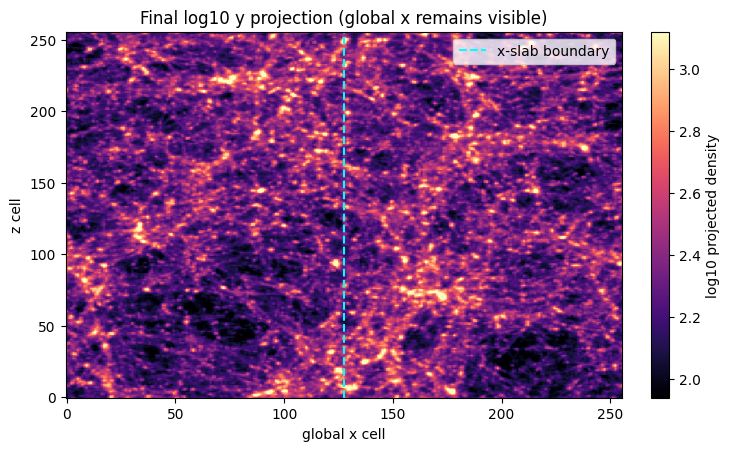

In [5]:
density_host = np.asarray(density)
active_total = run_summary["active_particles_total"]
mass_error = abs(density_host.sum() - active_total) / active_total

assert np.isfinite(density_host).all()
np.testing.assert_allclose(density_host.mean(), 1.0, rtol=2e-5, atol=2e-5)
np.testing.assert_allclose(density_host.sum(), active_total, rtol=2e-5)

print(f"density mean={density_host.mean():.8f}")
print(f"relative mass error={mass_error:.3e}")
print("capacity status: execution completed without an overflow diagnostic")

projection_y = density_host.sum(axis=1).T
log_projection_y = np.log10(np.clip(projection_y, 1e-6, None))
vmin, vmax = np.percentile(log_projection_y, (0.5, 99.5))
fig, ax = plt.subplots(figsize=(7.2, 4.4), constrained_layout=True)
image = ax.imshow(
    log_projection_y,
    origin="lower",
    cmap="magma",
    aspect="auto",
    vmin=vmin,
    vmax=vmax,
)
ax.axvline(slab_width - 0.5, color="cyan", linestyle="--", linewidth=1.5, label="x-slab boundary")
ax.set_xlabel("global x cell")
ax.set_ylabel("z cell")
ax.set_title("Final log10 y projection (global x remains visible)")
ax.legend(loc="upper right")
fig.colorbar(image, ax=ax, label="log10 projected density")
plt.show()


An x projection would hide the decomposed axis and therefore hide the slab boundary.  The
y projection above keeps global x visible, making it the useful diagnostic view for this
decomposition.  A trustworthy production run must reproduce the ownership and mass checks
and emit no capacity-overflow message.
